## Problem statement:
Given a sorted array of integers, and a target value, find the index of the target value in the array. If the target value is not present in the array, return -1.

## Iterative solution

First, see if you can code an iterative solution (i.e., one that uses loops). If you get stuck, the solution is below.

In [1]:
def binary_search(array, target):
    start_index = 0
    end_index = len(array) - 1
    
    while start_index <= end_index:
        mid_index = (start_index + end_index)//2        # integer division in Python 3
        
        mid_element = array[mid_index]
        
        if target == mid_element:                       # we have found the element
            return mid_index
        
        elif target < mid_element:                      # the target is less than mid element
            end_index = mid_index - 1                   # we will only search in the left half
        
        else:                                           # the target is greater than mid element
            start_index = mid_element + 1               # we will search only in the right half
    
    return -1

In [2]:
def test_function(test_case):
    answer = binary_search(test_case[0], test_case[1])
    if answer == test_case[2]:
        print("Pass!")
    else:
        print("Fail!")

In [3]:
array = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
target = 6
index = 6
test_case = [array, target, index]
test_function(test_case)

Pass!


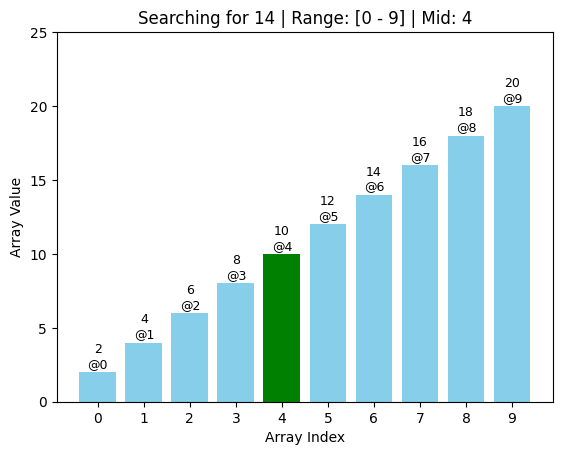

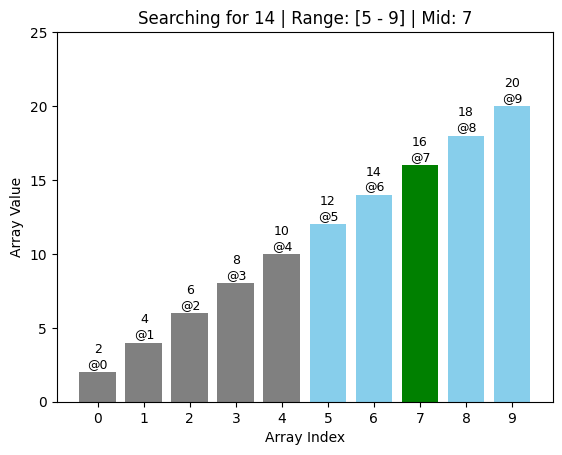

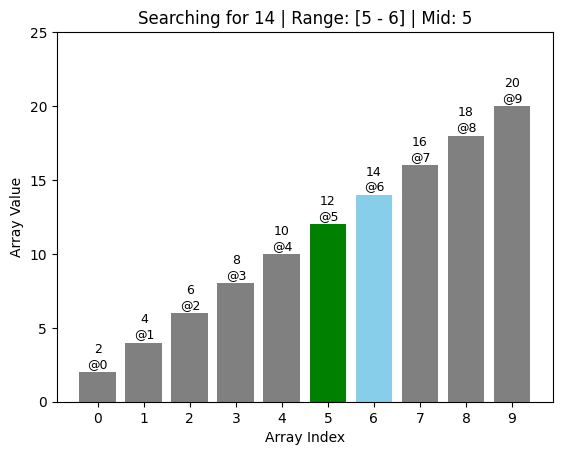

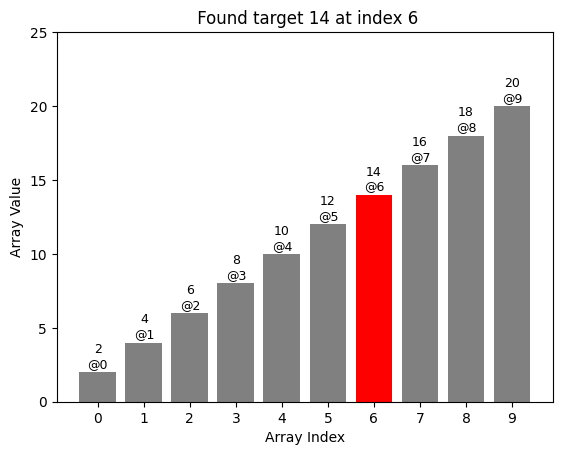


✅ Target found at index: 6


In [5]:
import matplotlib.pyplot as plt
import time

def visualize_binary_search(array, target):
    def helper(start_index, end_index):
        if start_index > end_index:
            draw_array(array, -1, start_index, end_index, target, found=False)
            return -1

        mid_index = (start_index + end_index) // 2
        mid_element = array[mid_index]

        if mid_element == target:
            draw_array(array, mid_index, start_index, end_index, target, found=True)
            return mid_index
        elif target < mid_element:
            draw_array(array, mid_index, start_index, end_index, target)
            return helper(start_index, mid_index - 1)
        else:
            draw_array(array, mid_index, start_index, end_index, target)
            return helper(mid_index + 1, end_index)

    return helper(0, len(array) - 1)

def draw_array(array, mid_index, start_index, end_index, target, found=False):
    plt.clf()
    bar_colors = ['gray'] * len(array)

    # Highlight current search range
    for i in range(start_index, end_index + 1):
        bar_colors[i] = 'skyblue'

    # Highlight mid index
    if mid_index != -1:
        bar_colors[mid_index] = 'green' if not found else 'red'

    # Draw bars
    bars = plt.bar(range(len(array)), array, color=bar_colors)
    
    # Add text labels (index and value)
    for idx, bar in enumerate(bars):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.3,
                 f"{array[idx]}\n@{idx}", ha='center', fontsize=9)

    # Add titles and info
    if found:
        title = f" Found target {target} at index {mid_index}"
    else:
        title = f"Searching for {target} | Range: [{start_index} - {end_index}] | Mid: {mid_index}"
    plt.title(title, fontsize=12)
    plt.ylim(0, max(array) + 5)
    plt.xticks(range(len(array)))
    plt.xlabel("Array Index")
    plt.ylabel("Array Value")
    plt.pause(1)  # Pause to see the step

# --- Example Usage ---
if __name__ == "__main__":
    array = [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]
    target = 14

    plt.ion()
    result = visualize_binary_search(array, target)
    plt.ioff()
    plt.show()

    print("\n✅ Target found at index:", result if result != -1 else "❌ Not found")


In [12]:
def binary_search_recursive(array, target):
    return binary_search_recursive_soln(array, target, 0, len(array) - 1)

def binary_search_recursive_soln(array, target, start_index, end_index):
    if start_index > end_index:
        return -1
    
    mid_index = (start_index + end_index)//2
    mid_element = array[mid_index]
    
    if mid_element == target:
        return mid_index
    elif target < mid_element:
        return binary_search_recursive_soln(array, target, start_index, mid_index - 1)
    else:
        return binary_search_recursive_soln(array, target, mid_index + 1, end_index)
        

In [13]:
def test_function(test_case):
    answer = binary_search_recursive(test_case[0], test_case[1])
    if answer == test_case[2]:
        print("Pass!")
    else:
        print("Fail!")

In [14]:
array = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
target = 4
index = 4
test_case = [array, target, index]
test_function(test_case)

Pass!


## Trie using Defaultdict (Optional)
This is an optional section. Feel free to skip this and go to the next section of the classroom.

A cleaner way to build a trie is with a Python default dictionary. The following `TrieNod` class is using `collections.defaultdict` instead of a normal dictionary.

In [39]:
import collections

class TrieNode:
    def __init__(self):
        self.children = collections.defaultdict(TrieNode)
        self.is_word = False
root = TrieNode()

child_h = root.children['h']
print(child_h.children) 
print(child_h.is_word) 
child_h.children["a"] = 3
print(child_h.children) 

defaultdict(<class '__main__.TrieNode'>, {})
False
defaultdict(<class '__main__.TrieNode'>, {'a': 3})


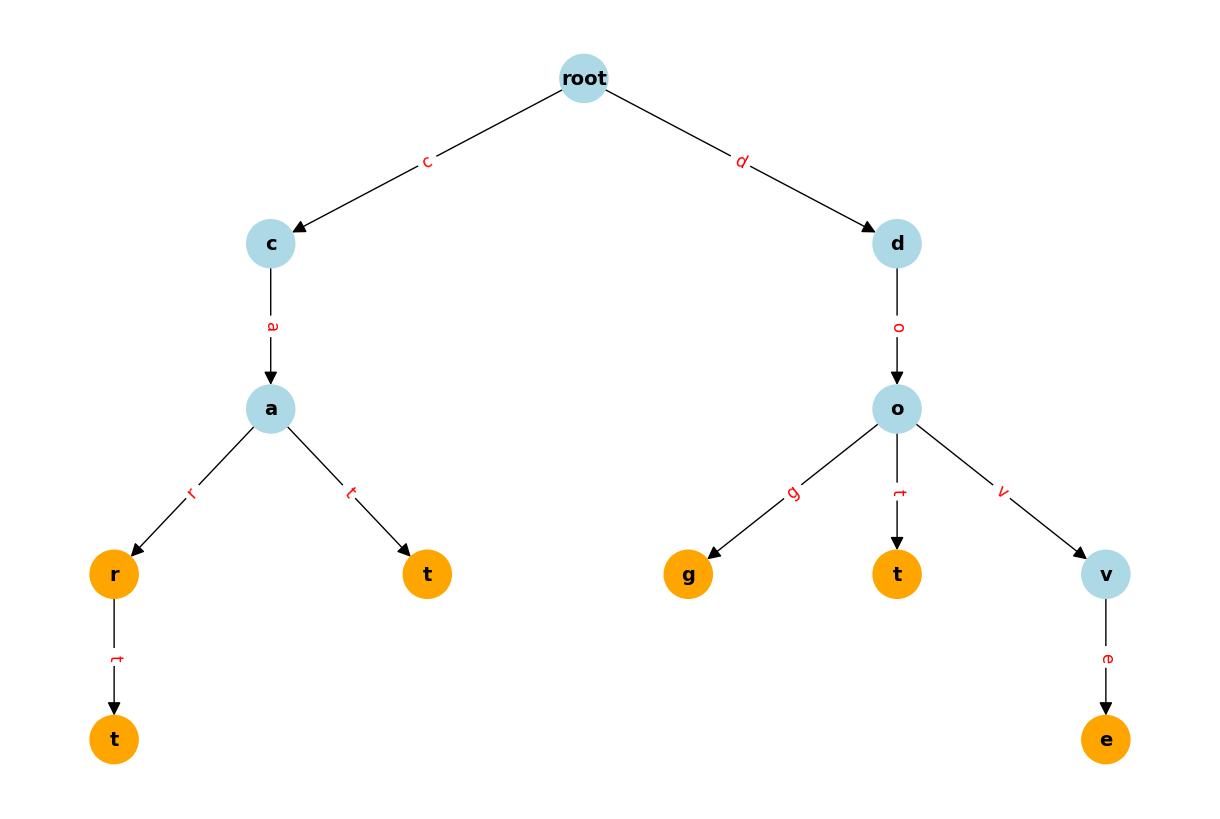

In [ ]:
import collections
import matplotlib.pyplot as plt
import networkx as nx

class TrieNode:
    def __init__(self):
        self.children = collections.defaultdict(TrieNode)
        self.is_word = False

class Trie(object):
    def __init__(self):
        self.root = TrieNode()

    def add(self, word):
        current_node = self.root
        for char in word:
            if char not in current_node.children:
                current_node.children[char] = TrieNode()
            current_node = current_node.children[char]
        current_node.is_word = True

def build_graph(trie):
    G = nx.DiGraph()

    def add_edges(node, node_id):
        for char, child in sorted(node.children.items()):
            child_id = f"{node_id}-{char}"
            G.add_edge(node_id, child_id, label=char)
            add_edges(child, child_id)
        G.nodes[node_id]['is_word'] = node.is_word

    root_id = "root"
    G.add_node(root_id, label="root", is_word=False)
    add_edges(trie.root, root_id)
    return G

def hierarchy_pos(G, root='root', width=1., vert_gap=0.2, vert_loc=0, xcenter=0.5):
    '''
    Position nodes in a hierarchy (tree) layout.

    Arguments:
        G: the graph (must be a tree)
        root: the root node id
        width: horizontal space allocated for this branch - avoids overlap
        vert_gap: gap between levels vertically
        vert_loc: vertical location of root
        xcenter: horizontal center of root
    Returns:
        pos: dict of node positions keyed by node id
    '''
    def _hierarchy_pos(G, root, left, right, vert_loc, pos):
        pos[root] = ((left + right) / 2, vert_loc)
        children = list(G.successors(root))
        if len(children) != 0:
            dx = (right - left) / len(children)
            nextx = left
            for child in children:
                next_right = nextx + dx
                _hierarchy_pos(G, child, nextx, next_right, vert_loc - vert_gap, pos)
                nextx += dx
    pos = {}
    _hierarchy_pos(G, root, 0, width, vert_loc, pos)
    return pos

def visualize_trie(trie, title=None):
    G = build_graph(trie)
    pos = hierarchy_pos(G)

    labels = {}
    colors = []
    for node in G.nodes(data=True):
        node_id = node[0]
        is_word = node[1].get('is_word', False)
        label = node_id.split('-')[-1] if node_id != "root" else "root"
        labels[node_id] = label
        colors.append('orange' if is_word else 'lightblue')

    edge_labels = {(u, v): d['label'] for u, v, d in G.edges(data=True)}

    plt.figure(figsize=(12, 8))
    nx.draw(G, pos, labels=labels, with_labels=True, node_color=colors,
            node_size=1200, font_size=14, font_weight='bold', arrowsize=20)
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=12)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()

# Example usage:
trie = Trie()
words = ["cat", "car", "cart", "dog", "dove", "dot"]
for w in words:
    trie.add(w)

visualize_trie(trie)


In [33]:
import collections

class TrieNode:
    def __init__(self):
        self.children = collections.defaultdict(TrieNode)
        self.is_word = False

class Trie(object):
    def __init__(self):
        self.root = TrieNode()

    def add(self, word):
        """
        Add `word` to trie
        """
        current_node = self.root

        for char in word:
            # Create the child node if it doesn't exist
            if char not in current_node.children:
                current_node.children[char] = TrieNode()

            current_node = current_node.children[char]

        # Mark the end of the word
        current_node.is_word = True

    def exists(self, word):
        """
        Check if word exists in trie
        """
        current_node = self.root

        for char in word:
            if char not in current_node.children:
                return False

            current_node = current_node.children[char]

        return current_node.is_word


In [42]:
import collections

class TrieNode:
    def __init__(self):
        self.children = collections.defaultdict(TrieNode)
        self.is_word = False

class Trie(object):
    def __init__(self):
        self.root = TrieNode()

    def add(self, word):
        """
        Add `word` to trie
        """
        print(f"\n[ADD] Adding word: '{word}'")
        current_node = self.root

        for i, char in enumerate(word):
            if char not in current_node.children:
                print(f"  [ADD] '{char}' not found at index {i}, creating new node")
            else:
                print(f"  [ADD] '{char}' exists at index {i}, moving to next")

            current_node = current_node.children[char]

        current_node.is_word = True
        print(f"  [ADD] Word '{word}' added, last node marked as word\n")

    def exists(self, word):
        """
        Check if word exists in trie
        """
        print(f"\n[EXISTS] Checking existence for word: '{word}'")
        current_node = self.root

        for i, char in enumerate(word):
            if char not in current_node.children:
                print(f"  [EXISTS] '{char}' not found at index {i}, word does not exist\n")
                return False

            print(f"  [EXISTS] '{char}' found at index {i}, moving to next")
            current_node = current_node.children[char]

        if current_node.is_word:
            print(f"  [EXISTS] Word '{word}' found (is_word=True)\n")
            return True
        else:
            print(f"  [EXISTS] Prefix '{word}' found, but is not a complete word\n")
            return False

    def print_trie(self):
        def dfs(node, prefix='', depth=0):
            indent = '  ' * depth
            for char, child in node.children.items():
                marker = '*' if child.is_word else ''
                print(f"{indent}- {char}{marker}")
                dfs(child, prefix + char, depth + 1)

        print("Trie structure:")
        dfs(self.root)


In [43]:
# Add words
valid_words = ['the', 'a', 'there', 'answer', 'any', 'by', 'bye', 'their']
word_trie = Trie()
for valid_word in valid_words:
    word_trie.add(valid_word)

word_trie.print_trie()

# Tests
assert word_trie.exists('the')
assert word_trie.exists('any')
assert not word_trie.exists('these')
assert not word_trie.exists('zzz')
print('All tests passed!')


[ADD] Adding word: 'the'
  [ADD] 't' not found at index 0, creating new node
  [ADD] 'h' not found at index 1, creating new node
  [ADD] 'e' not found at index 2, creating new node
  [ADD] Word 'the' added, last node marked as word


[ADD] Adding word: 'a'
  [ADD] 'a' not found at index 0, creating new node
  [ADD] Word 'a' added, last node marked as word


[ADD] Adding word: 'there'
  [ADD] 't' exists at index 0, moving to next
  [ADD] 'h' exists at index 1, moving to next
  [ADD] 'e' exists at index 2, moving to next
  [ADD] 'r' not found at index 3, creating new node
  [ADD] 'e' not found at index 4, creating new node
  [ADD] Word 'there' added, last node marked as word


[ADD] Adding word: 'answer'
  [ADD] 'a' exists at index 0, moving to next
  [ADD] 'n' not found at index 1, creating new node
  [ADD] 's' not found at index 2, creating new node
  [ADD] 'w' not found at index 3, creating new node
  [ADD] 'e' not found at index 4, creating new node
  [ADD] 'r' not found at index 5,

Given a string s representing a valid expression, implement a basic calculator to evaluate it, and return the result of the evaluation.

Note: You are not allowed to use any built-in function which evaluates strings as mathematical expressions, such as eval().

 

Example 1:

Input: s = "1 + 1"
Output: 2
Example 2:

Input: s = " 2-1 + 2 "
Output: 3
Example 3:

Input: s = "(1+(4+5+2)-3)+(6+8)"
Output: 23
 

Constraints:

1 <= s.length <= 3 * 105
s consists of digits, '+', '-', '(', ')', and ' '.
s represents a valid expression.
'+' is not used as a unary operation (i.e., "+1" and "+(2 + 3)" is invalid).
'-' could be used as a unary operation (i.e., "-1" and "-(2 + 3)" is valid).
There will be no two consecutive operators in the input.
Every number and running calculation will fit in a signed 32-bit integer.

In [15]:
def calculate(s: str) -> int:
    def precedence(op):
        if op in ('+', '-'):
            return 1
        if op in ('*', '/'):
            return 2
        return 0

    def apply_op(a, b, op):
        if op == '+':
            return a + b
        if op == '-':
            return a - b
        if op == '*':
            return a * b
        if op == '/':
            # integer division truncating toward zero
            return int(a / b)

    nums = []   # stack for numbers
    ops = []    # stack for operators

    i = 0
    n = len(s)
    while i < n:
        char = s[i]

        if char == ' ':
            i += 1
            continue

        if char.isdigit():
            # parse full number
            val = 0
            while i < n and s[i].isdigit():
                val = val * 10 + int(s[i])
                i += 1
            nums.append(val)
            # continue to next iteration, because i already moved
            continue

        if char == '(':
            ops.append(char)

        elif char == ')':
            # compute until '('
            while ops and ops[-1] != '(':
                op = ops.pop()
                b = nums.pop()
                a = nums.pop()
                nums.append(apply_op(a, b, op))
            ops.pop()  # remove '('

        else:
            # operator encountered
            while ops and precedence(ops[-1]) >= precedence(char):
                op = ops.pop()
                b = nums.pop()
                a = nums.pop()
                nums.append(apply_op(a, b, op))
            ops.append(char)

        i += 1

    # after parsing, apply remaining ops
    while ops:
        op = ops.pop()
        b = nums.pop()
        a = nums.pop()
        nums.append(apply_op(a, b, op))

    return nums[-1]


In [16]:
print(calculate("1 + 1"))               # 2
print(calculate(" 2-1 + 2 "))           # 3
print(calculate("(1+(4+5+2)-3)+(6+8)")) # 23
print(calculate("3+2*2"))                # 7
print(calculate(" 3/2 "))                # 1
print(calculate(" 3+5 / 2 "))            # 5


2
3
23
7
1
5


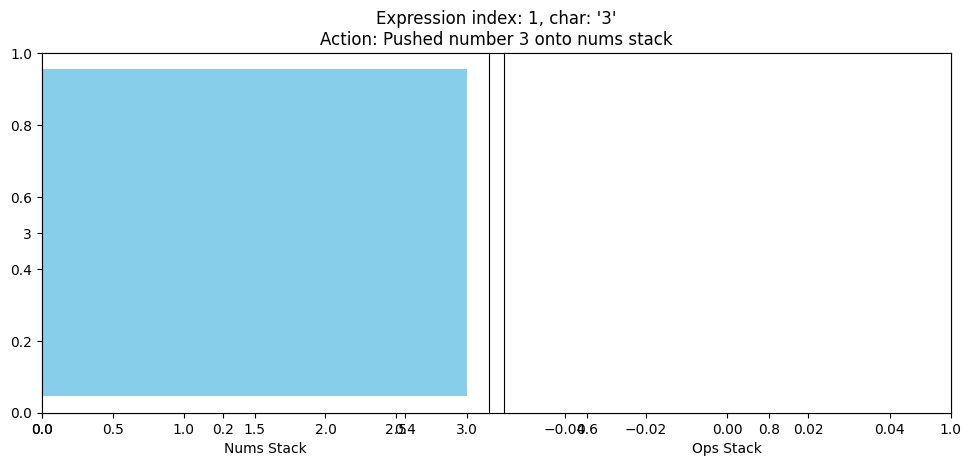

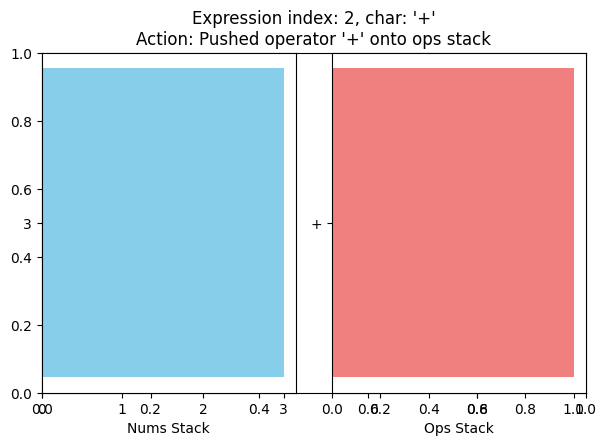

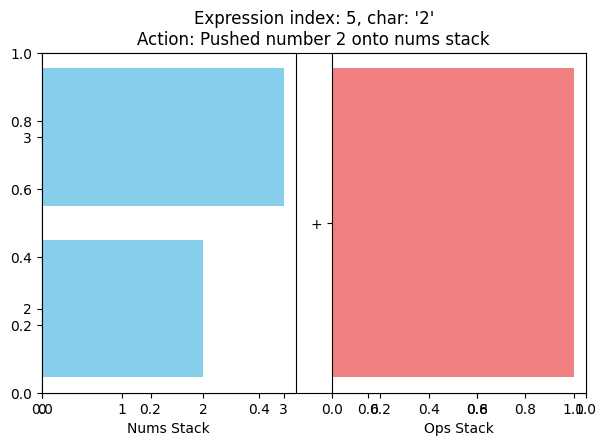

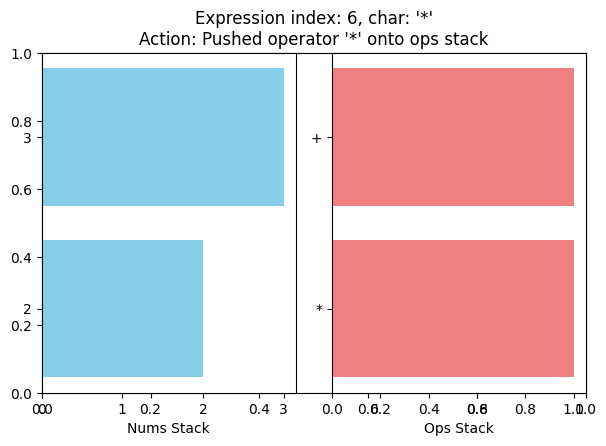

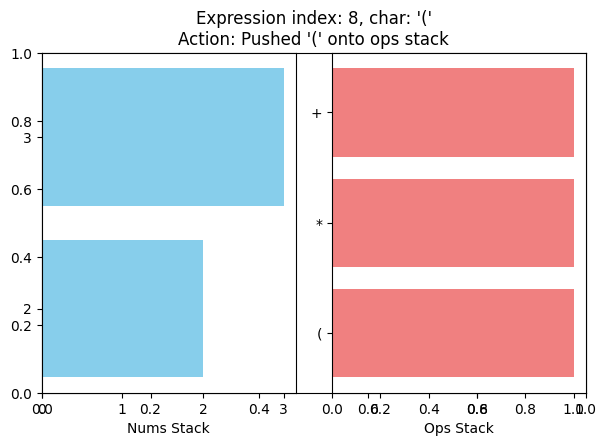

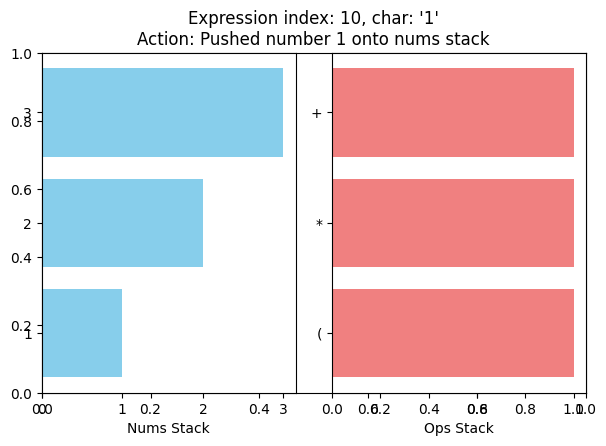

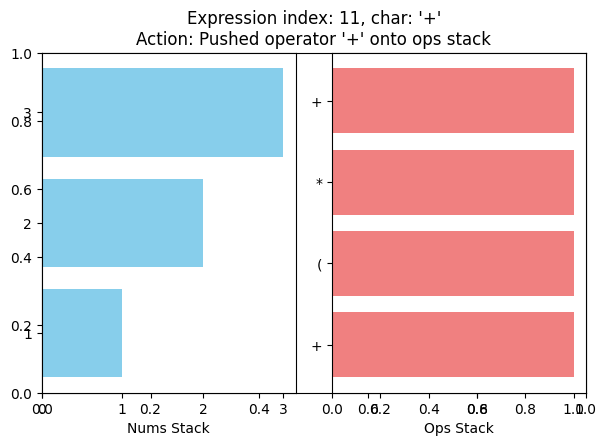

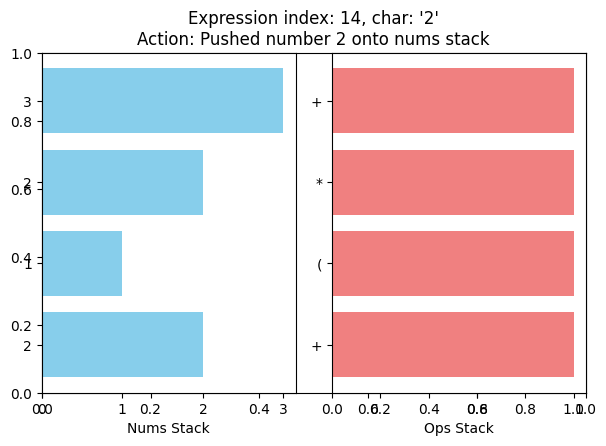

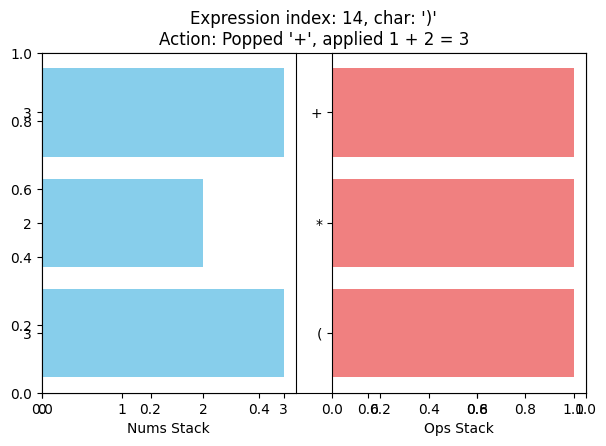

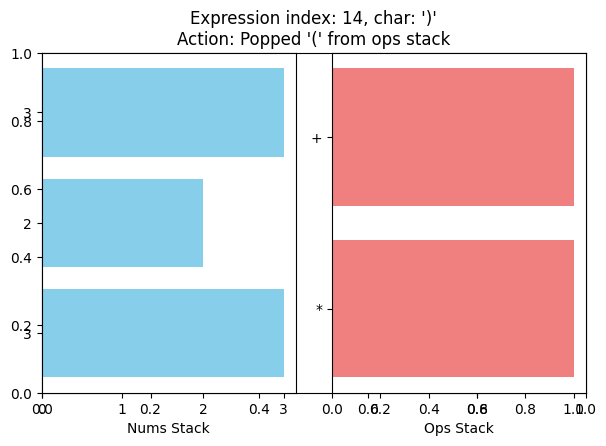

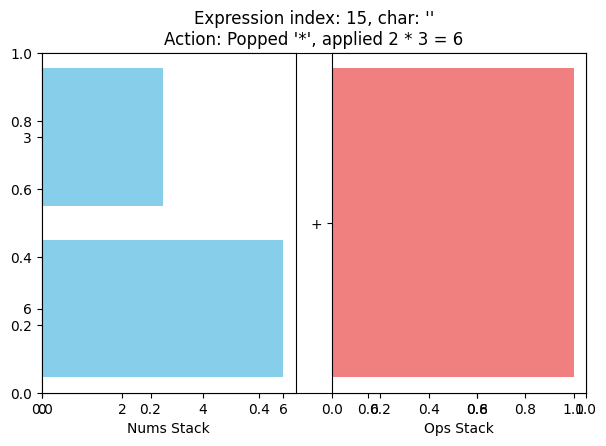

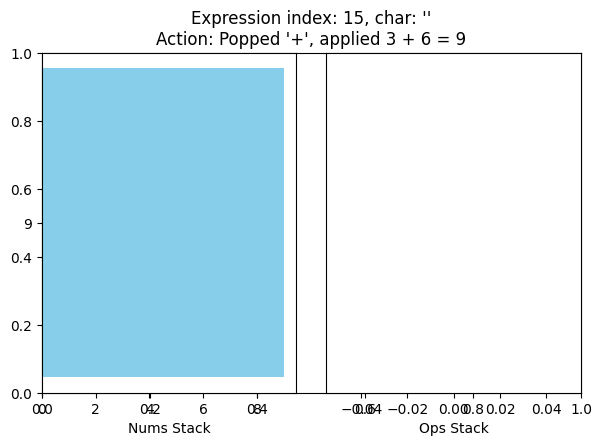

Result: 9


In [ ]:
import matplotlib.pyplot as plt
import time

def calculate_visual_simple(s: str, delay=1.5) -> int:
    def precedence(op):
        if op in ('+', '-'):
            return 1
        if op in ('*', '/'):
            return 2
        return 0

    def apply_op(a, b, op):
        if op == '+':
            return a + b
        if op == '-':
            return a - b
        if op == '*':
            return a * b
        if op == '/':
            return int(a / b)

    nums = []
    ops = []

    i = 0
    n = len(s)

    def plot_state(i, action_desc):
        plt.clf()
        # Show full expression with pointer ^
        expr_display = s[:i] + '|' + s[i:] if i < n else s + '|'
        plt.text(0, 1.2, expr_display, fontsize=14, fontfamily='monospace')

        plt.text(0, 1.0, action_desc, fontsize=12, color='blue')

        # Plot nums stack
        plt.subplot(1, 2, 1)
        plt.barh(range(len(nums)), nums, color='skyblue')
        plt.yticks(range(len(nums)), [str(x) for x in nums])
        plt.gca().invert_yaxis()
        plt.title('Nums Stack')

        # Plot ops stack
        plt.subplot(1, 2, 2)
        plt.barh(range(len(ops)), [1]*len(ops), tick_label=ops, color='lightcoral')
        plt.gca().invert_yaxis()
        plt.title('Ops Stack')

        plt.tight_layout()
        plt.pause(delay)

    plt.figure(figsize=(10,5))
    plt.ion()

    while i < n:
        char = s[i]

        if char == ' ':
            i += 1
            continue

        if char.isdigit():
            val = 0
            start_i = i
            while i < n and s[i].isdigit():
                val = val * 10 + int(s[i])
                i += 1
            nums.append(val)
            plot_state(i, f"Pushed number {val}")
            continue

        if char == '(':
            ops.append(char)
            plot_state(i, "Pushed '(' onto ops stack")

        elif char == ')':
            while ops and ops[-1] != '(':
                op = ops.pop()
                b = nums.pop()
                a = nums.pop()
                res = apply_op(a, b, op)
                nums.append(res)
                plot_state(i, f"Applied {a} {op} {b} = {res}")
            ops.pop()  # remove '('
            plot_state(i, "Popped '(' from ops stack")

        else:
            while ops and precedence(ops[-1]) >= precedence(char):
                op = ops.pop()
                b = nums.pop()
                a = nums.pop()
                res = apply_op(a, b, op)
                nums.append(res)
                plot_state(i, f"Applied {a} {op} {b} = {res}")
            ops.append(char)
            plot_state(i, f"Pushed operator '{char}'")

        i += 1

    while ops:
        op = ops.pop()
        b = nums.pop()
        a = nums.pop()
        res = apply_op(a, b, op)
        nums.append(res)
        plot_state(i, f"Applied {a} {op} {b} = {res}")

    plt.ioff()
    plt.show()

    return nums[-1]

# Try it out
expr = "3 + 2 * (1 + 2)"
result = calculate_visual_simple(expr, delay=1)
print("Final result:", result)


In [ ]:
class Heap:
    def __init__(self, initial_size=10):
        self.cbt = [None for _ in range(initial_size)]  # initialize arrays
        self.next_index = 0  # denotes next index where new element should go

    def insert(self, data):
        # insert element at the next index
        self.cbt[self.next_index] = data

        # heapify
        self._up_heapify()

        # increase index by 1
        self.next_index += 1

        # double the array and copy elements if next_index goes out of array bounds
        if self.next_index >= len(self.cbt):
            temp = self.cbt
            self.cbt = [None for _ in range(2 * len(self.cbt))]

            for index in range(self.next_index):
                self.cbt[index] = temp[index]

    def remove(self):
        if self.size() == 0:
            return None
        self.next_index -= 1

        to_remove = self.cbt[0]
        last_element = self.cbt[self.next_index]

        # place last element of the cbt at the root
        self.cbt[0] = last_element

        # we do not remove the elementm, rather we allow next `insert` operation to overwrite it
        self.cbt[self.next_index] = to_remove
        self._down_heapify()
        return to_remove

    def size(self):
        return self.next_index 

    def is_empty(self):
        return self.size() == 0

    def _up_heapify(self):
        # print("inside heapify")
        child_index = self.next_index

        while child_index >= 1:
            parent_index = (child_index - 1) // 2
            parent_element = self.cbt[parent_index]
            child_element = self.cbt[child_index]

            if parent_element > child_element:
                self.cbt[parent_index] = child_element
                self.cbt[child_index] = parent_element

                child_index = parent_index
            else:
                break

    def _down_heapify(self):
        parent_index = 0

        while parent_index < self.next_index:
            left_child_index = 2 * parent_index + 1
            right_child_index = 2 * parent_index + 2

            parent = self.cbt[parent_index]
            left_child = None
            right_child = None

            min_element = parent

            # check if left child exists
            if left_child_index < self.next_index:
                left_child = self.cbt[left_child_index]

            # check if right child exists
            if right_child_index < self.next_index:
                right_child = self.cbt[right_child_index]

            # compare with left child
            if left_child is not None:
                min_element = min(parent, left_child)

            # compare with right child
            if right_child is not None:
                min_element = min(right_child, min_element)

            # check if parent is rightly placed
            if min_element == parent:
                return

            if min_element == left_child:
                self.cbt[left_child_index] = parent
                self.cbt[parent_index] = min_element
                parent = left_child_index

            elif min_element == right_child:
                self.cbt[right_child_index] = parent
                self.cbt[parent_index] = min_element
                parent = right_child_index

    def get_minimum(self):
        # Returns the minimum element present in the heap
        if self.size() == 0:
            return None
        return self.cbt[0]

Sam records when they wake up every morning. Assuming Sam always wakes up in the same hour, use bubble sort to sort by earliest to latest.




In [25]:
def bubble_sort_1(l):
    for iteration in range(len(l)):
        for index in range(1, len(l)):
            this = l[index]
            prev = l[index - 1]

            if prev <= this:
                continue

            l[index] = prev
            l[index - 1] = this

In [26]:
wakeup_times = [16,49,3,12,56,49,55,22,13,46,19,55,46,13,25,56,9,48,45]
bubble_sort_1(wakeup_times)
print ("Pass" if (wakeup_times[0] == 3) else "Fail")

Pass


In [28]:
def sort_a_little_bit(items, begin_index, end_index):    
    left_index = begin_index
    pivot_index = end_index
    pivot_value = items[pivot_index]

    while (pivot_index != left_index):

        item = items[left_index]

        if item <= pivot_value:
            left_index += 1
            continue

        items[left_index] = items[pivot_index - 1]
        items[pivot_index - 1] = pivot_value
        items[pivot_index] = item
        pivot_index -= 1
    
    return pivot_index

def sort_all(items, begin_index, end_index):
    if end_index <= begin_index:
        return
    
    pivot_index = sort_a_little_bit(items, begin_index, end_index)
    sort_all(items, begin_index, pivot_index - 1)
    sort_all(items, pivot_index + 1, end_index)
    
def quicksort(items):
    sort_all(items, 0, len(items) - 1)
    
items = [8, 3, 1, 7, 0, 10, 2]
quicksort(items)
print(items)

[0, 1, 2, 3, 7, 8, 10]


In [29]:
def sort_a_little_bit(items, begin_index, end_index):    
    left_index = begin_index
    pivot_index = end_index
    pivot_value = items[pivot_index]

    print(f"\n🔹 Partitioning: {items[begin_index:end_index+1]} (pivot={pivot_value})")

    while pivot_index != left_index:
        item = items[left_index]

        if item <= pivot_value:
            left_index += 1
            continue

        print(f"  ↪ Swapping '{item}' (too big) with '{items[pivot_index - 1]}' before pivot '{pivot_value}'")
        
        # Perform the pivot shuffle
        items[left_index] = items[pivot_index - 1]
        items[pivot_index - 1] = pivot_value
        items[pivot_index] = item
        pivot_index -= 1

        print(f"  → Now: {items}")

    print(f"✅ Pivot '{pivot_value}' placed at index {pivot_index}: {items}")
    return pivot_index

def sort_all(items, begin_index, end_index):
    if end_index <= begin_index:
        return
    
    pivot_index = sort_a_little_bit(items, begin_index, end_index)
    sort_all(items, begin_index, pivot_index - 1)
    sort_all(items, pivot_index + 1, end_index)
    
def quicksort(items):
    print(f"🔄 Starting quicksort on: {items}")
    sort_all(items, 0, len(items) - 1)
    print(f"✅ Fully sorted: {items}")
    
items = [8, 3, 1, 7, 0, 10, 2]
quicksort(items)


🔄 Starting quicksort on: [8, 3, 1, 7, 0, 10, 2]

🔹 Partitioning: [8, 3, 1, 7, 0, 10, 2] (pivot=2)
  ↪ Swapping '8' (too big) with '10' before pivot '2'
  → Now: [10, 3, 1, 7, 0, 2, 8]
  ↪ Swapping '10' (too big) with '0' before pivot '2'
  → Now: [0, 3, 1, 7, 2, 10, 8]
  ↪ Swapping '3' (too big) with '7' before pivot '2'
  → Now: [0, 7, 1, 2, 3, 10, 8]
  ↪ Swapping '7' (too big) with '1' before pivot '2'
  → Now: [0, 1, 2, 7, 3, 10, 8]
✅ Pivot '2' placed at index 2: [0, 1, 2, 7, 3, 10, 8]

🔹 Partitioning: [0, 1] (pivot=1)
✅ Pivot '1' placed at index 1: [0, 1, 2, 7, 3, 10, 8]

🔹 Partitioning: [7, 3, 10, 8] (pivot=8)
  ↪ Swapping '10' (too big) with '10' before pivot '8'
  → Now: [0, 1, 2, 7, 3, 8, 10]
✅ Pivot '8' placed at index 5: [0, 1, 2, 7, 3, 8, 10]

🔹 Partitioning: [7, 3] (pivot=3)
  ↪ Swapping '7' (too big) with '7' before pivot '3'
  → Now: [0, 1, 2, 3, 7, 8, 10]
✅ Pivot '3' placed at index 3: [0, 1, 2, 3, 7, 8, 10]
✅ Fully sorted: [0, 1, 2, 3, 7, 8, 10]


### Problem Statement
Given an unsorted array `Arr` with `n` positive integers. Find the $k^{th}$ smallest element in the given array, using Divide & Conquer approach. 

**Input**: Unsorted array `Arr` and an integer `k` where $1 \leq k \leq n$ <br>
**Output**: The $k^{th}$ smallest element of array `Arr`<br>


**Example 1**<br>
Arr = `[6, 80, 36, 8, 23, 7, 10, 12, 42, 99]`<br>
k = `10`<br>
Output = `99`<br>

**Example 2**<br>
Arr = `[6, 80, 36, 8, 23, 7, 10, 12, 42, 99]`<br>
k = `5`<br>
Output = `12`<br>

---

In [30]:
def fastSelect(Arr, k):                         # k is an index
    n = len(Arr)                                # length of the original array
    
    if(k>0 and k <= n):                         # k should be a valid index         
        # Helper variables
        setOfMedians = []
        Arr_Less_P = []
        Arr_Equal_P = []
        Arr_More_P = []
        i = 0
        
        # Step 1 - Break Arr into groups of size 5
        # Step 2 - For each group, sort and find median (middle). Add the median to setOfMedians
        while (i < n // 5):                     # n//5 gives the integer quotient of the division 
            median = findMedian(Arr, 5*i, 5)    # find median of each group of size 5
            setOfMedians.append(median)         
            i += 1

        # If n is not a multiple of 5, then a last group with size = n % 5 will be formed
        if (5*i < n): 
            median = findMedian(Arr, 5*i, n % 5)
            setOfMedians.append(median)
        
        # Step 3 - Find the median of setOfMedians
        if (len(setOfMedians) == 1):            # Base case for this task
            pivot = setOfMedians[0]
        elif (len(setOfMedians)>1):
            pivot = fastSelect(setOfMedians, (len(setOfMedians)//2))
        
        # Step 4 - Partition the original Arr into three sub-arrays
        for element in Arr:
            if (element<pivot):
                Arr_Less_P.append(element)
            elif (element>pivot):
                Arr_More_P.append(element)
            else:
                Arr_Equal_P.append(element)
        
        # Step 5 - Recurse based on the sizes of the three sub-arrays
        if (k <= len(Arr_Less_P)):
            return fastSelect(Arr_Less_P, k)
        
        elif (k > (len(Arr_Less_P) + len(Arr_Equal_P))):
            return fastSelect(Arr_More_P, (k - len(Arr_Less_P) - len(Arr_Equal_P)))
            
        else:
            return pivot     

# Helper function
def findMedian(Arr, start, size): 
    myList = [] 
    for i in range(start, start + size): 
        myList.append(Arr[i]) 
          
    # Sort the array  
    myList.sort() 
  
    # Return the middle element 
    return myList[size // 2] 

In [31]:
Arr = [6, 80, 36, 8, 23, 7, 10, 12, 42]
k = 5
print(fastSelect(Arr, k))        # Outputs 12

12


In [1]:
def rotated_array_search(input_list, number):
    left = 0
    right = len(input_list) - 1
    
    while left <= right:
        mid = (left + right) // 2

        if input_list[mid] == number:
            return mid

        # Determine which half is sorted
        if input_list[left] <= input_list[mid]:  # Left half is sorted
            if input_list[left] <= number < input_list[mid]:
                right = mid - 1
            else:
                left = mid + 1
        else:  # Right half is sorted
            if input_list[mid] < number <= input_list[right]:
                left = mid + 1
            else:
                right = mid - 1
    
    return -1


In [2]:
def linear_search(input_list, number):
    for index, element in enumerate(input_list):
        if element == number:
            return index
    return -1
    
def test_function(test_case):
    input_list = test_case[0]
    number = test_case[1]
    if linear_search(input_list, number) == rotated_array_search(input_list, number):
        print("Pass")
    else:
        print("Fail")

test_function([[6, 7, 8, 9, 10, 1, 2, 3, 4], 6])
test_function([[6, 7, 8, 9, 10, 1, 2, 3, 4], 1])
test_function([[6, 7, 8, 1, 2, 3, 4], 8])
test_function([[6, 7, 8, 1, 2, 3, 4], 1])
test_function([[6, 7, 8, 1, 2, 3, 4], 10])

Pass
Pass
Pass
Pass
Pass
